# 大数定律（Law of Large Numbers）

> 从"抛一次硬币的随机"到"抛一万次的必然"——概率论的第一定律，也是"用数据学规律"这件事（统计学与机器学习）能够成立的数学地基。

**目录**

1. 引子：频率的稳定性
2. 预备知识：随机变量序列的收敛方式
3. 基石：马尔可夫不等式与切比雪夫不等式
4. 弱大数定律：伯努利 / 切比雪夫 / 辛钦
5. 强大数定律：Borel–Cantelli 与 Kolmogorov
6. 数值实验：看见收敛，看清速度
7. 哲学含义
8. 与深度学习的联系
9. 总结与思考题

## 1. 引子：频率的稳定性

### 1.1 历史上的"手抛实验"

| 实验者 | 抛硬币次数 $n$ | 正面频率 $f_n$ |
| --- | --- | --- |
| 蒲丰（Buffon，18 世纪） | 4040 | 0.5069 |
| Kerrich（二战战俘营，1940s） | 10000 | 0.5067 |
| 皮尔逊（Pearson） | 24000 | 0.5005 |

单次抛硬币的结果完全不可预测；但当成千上万次重复后，正面出现的**频率**却总是稳定在 0.5 附近——样本越多，离 0.5 越近。这种"频率的稳定性"是人类最早注意到的随机现象中的规律。

### 1.2 直觉需要变成定理

"频率会越来越接近概率"这句话听起来理所当然，但它其实隐藏着两个必须回答的数学问题：

- **凭什么稳定？** 每一次抛硬币都是独立的随机事件，随机加随机，为什么"平均下来"反而变得有规律？
- **"接近"是什么意思？** 频率数列 $\{f_n\}$ 不可能字面意义上单调逼近 $p$（中间会反复穿越 0.5 上下），那"收敛"到底指什么？

**大数定律（LLN）** 就是把这句直觉变成严格定理的一组结果，粗略地说：

> 在独立重复试验中，事件发生的频率（或随机变量的样本均值）会收敛到它的概率（期望）——问题只在于：**需要什么条件**，以及**以哪种意义收敛**。

这两个问题分别对应第 4 节（弱大数定律）、第 5 节（强大数定律）。先看一眼模拟，建立直观。

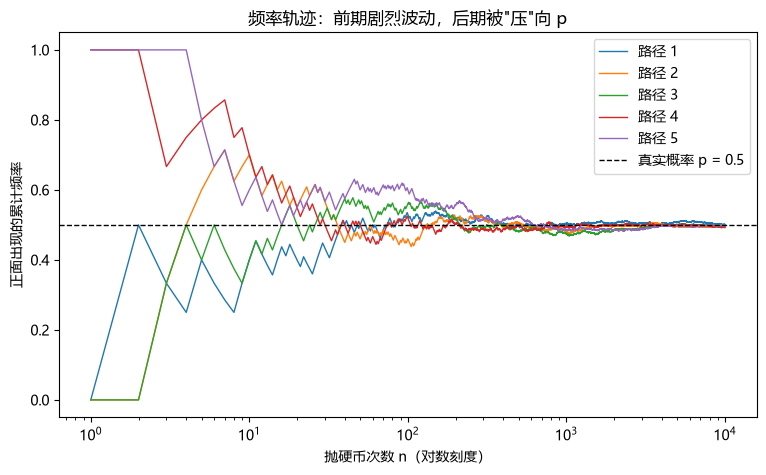

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# 中文字体设置（若后面的图出现乱码，重新运行本格即可）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

rng = np.random.default_rng(42)
n = 10000
flips = rng.random((5, n)) < 0.5                     # 5 条独立的抛硬币序列（1=正面）
freq = flips.cumsum(axis=1) / np.arange(1, n + 1)    # 逐步累计频率 f_n

plt.figure(figsize=(9, 5))
for i, f in enumerate(freq):
    plt.plot(np.arange(1, n + 1), f, lw=1, label=f'路径 {i + 1}')
plt.axhline(0.5, color='black', ls='--', lw=1, label='真实概率 p = 0.5')
plt.xscale('log')
plt.xlabel('抛硬币次数 n（对数刻度）')
plt.ylabel('正面出现的累计频率')
plt.title('频率轨迹：前期剧烈波动，后期被"压"向 p')
plt.legend(loc='upper right')
plt.show()

## 2. 预备知识：随机变量序列的"收敛"有几种？

大数定律各种版本的分野，就在于"收敛"二字的含义。这一节是理解弱/强大数定律的钥匙。

### 2.1 依概率收敛（convergence in probability）

$$X_n \xrightarrow{P} a \iff \forall \varepsilon>0,\ \lim_{n\to\infty}\mathbb{P}\big(|X_n-a|>\varepsilon\big)=0$$

直观：对任意给定精度 $\varepsilon$，只要 $n$ 足够大，$X_n$ 偏离 $a$ 超过 $\varepsilon$ 的概率就能任意小。它是 **"站在固定时刻 $n$ 处看单点"** 的说法。

### 2.2 几乎必然收敛（almost sure convergence，又称几乎处处收敛）

$$X_n \xrightarrow{a.s.} a \iff \mathbb{P}\Big(\big\{\omega:\ \lim_{n\to\infty} X_n(\omega)=a\big\}\Big)=1$$

直观：存在一个概率为 1 的事件集合，使得其中**每一条实现路径** $\omega$ 上的数列 $\{X_n(\omega)\}$ 都（在经典分析意义下）收敛到 $a$。它是 **"盯着整条路径看全程"** 的说法。

### 2.3 依分布收敛（convergence in distribution）

分布函数 $F_n(x)\to F(x)$ 在 $F$ 的连续点处成立。最弱的一种，只要求分布形状趋近，不要求随机变量本身靠近（后面中心极限定理用的就是它）。

### 2.4 三者的强弱关系

$$\text{几乎必然收敛} \;\Rightarrow\; \text{依概率收敛} \;\Rightarrow\; \text{依分布收敛}$$

反向一般不成立；依概率收敛能保证存在一个几乎必然收敛的**子列**（这个事实在第 5 节证明强大数定律时会真正派上用场）。

| 收敛方式 | 陈述对象 | 直观图像 | 强度 |
| --- | --- | --- | --- |
| 几乎必然 $a.s.$ | 整条样本路径 | 每条路径最终稳定下来 | 最强 |
| 依概率 $P$ | 固定的时刻 $n$ | 每个时刻处"坏"的概率小 | 中 |
| 依分布 $d$ | 分布函数 | 形状像即可 | 最弱 |

### 2.5 一个能把"弱与强的差距"具象化的例子

设 $X_n$ 相互独立，$\mathbb{P}(X_n=n)=\frac1n$，$\mathbb{P}(X_n=0)=1-\frac1n$。

- 依概率：$\mathbb{P}(|X_n|>\varepsilon)=\frac1n\to 0$，所以 $X_n\xrightarrow{P}0$，"弱"意义下一切正常；
- 路径：$\sum_n \mathbb{P}(X_n=n)=\sum_n \frac1n=\infty$，第 5 节将用 Borel–Cantelli 第二引理证明：以概率 1，$X_n$ 会**无穷多次**跳到 $n$——整条路径永远晃动，不几乎必然收敛。

所以"依概率收敛但几乎必然不收敛"不是吹毛求疵，而是真实存在的现象。弱大数定律管前者，强大数定律管后者。

## 3. 基石：马尔可夫不等式与切比雪夫不等式

大数定律证明的全部技术核心，是一条"用低阶矩控制尾部概率"的不等式。

### 3.1 马尔可夫不等式

**定理** 设非负随机变量 $X\ge 0$ 且期望存在，则对任意 $a>0$：

$$\mathbb{P}(X\ge a)\ \le\ \frac{\mathbb{E}[X]}{a}$$

**推导**（连续情形一行即得；离散情形把积分换成求和完全类似）：

$$\mathbb{E}[X]=\int_0^\infty x\,d\mathbb{P}\ \ge\ \int_{\{x\ge a\}} x\,d\mathbb{P}\ \ge\ a\int_{\{x\ge a\}} d\mathbb{P}\ =\ a\,\mathbb{P}(X\ge a)$$

直觉：非负变量的平均值越大，其概率质量就不可能全躲在小值处——**均值"托住"了尾部**。

### 3.2 切比雪夫不等式（1867）

**定理** 设 $X$ 的期望 $\mu$ 与方差 $\sigma^2$ 存在，则对任意 $\varepsilon>0$：

$$\mathbb{P}\big(|X-\mu|\ge\varepsilon\big)\ \le\ \frac{\sigma^2}{\varepsilon^2}$$

**推导**：把马尔可夫不等式用在非负变量 $(X-\mu)^2$ 上，取 $a=\varepsilon^2$：

$$\mathbb{P}\big(|X-\mu|\ge\varepsilon\big)=\mathbb{P}\big((X-\mu)^2\ge\varepsilon^2\big)\ \le\ \frac{\mathbb{E}\big[(X-\mu)^2\big]}{\varepsilon^2}=\frac{\sigma^2}{\varepsilon^2}$$

等价的"集中"写法：

$$\mathbb{P}\big(|X-\mu|<\varepsilon\big)\ \ge\ 1-\frac{\sigma^2}{\varepsilon^2}$$

> 注：单侧版本（Cantelli 不等式，1928）更紧：$\mathbb{P}(X-\mu\ge\varepsilon)\le\dfrac{\sigma^2}{\sigma^2+\varepsilon^2}$。

### 3.3 它为什么是大数定律的钥匙

- 它**只用了均值与方差两个数**就约束住任意尾部概率——信息要求极少，普适性极强；
- 它把"集中的责任"完全交给方差：方差越小，概率质量越向 $\mu$ 集中；
- 下一节将证明样本均值的方差按 $1/n$ 塌缩，于是尾部概率 $\propto 1/n\to 0$——弱大数定律即刻到手。

## 4. 弱大数定律：三种经典形态

统一句式：**样本均值 $\bar X_n=\frac1n\sum_i X_i$ 在什么条件下、依概率收敛到哪里？**

### 4.1 切比雪夫大数定律

**定理** 设 $X_1,X_2,\dots$ 两两独立（**不要求同分布**），方差一致有界 $\mathrm{Var}(X_i)\le C$，且 $\frac1n\sum_{i}\mathbb{E}[X_i]\to\mu$，则

$$\bar X_n\xrightarrow{P}\mu$$

**推导**（三步曲——全文最重要的计算，建议动手过一遍）：

**第一步：算期望。**

$$\mathbb{E}[\bar X_n]=\frac1n\sum_{i=1}^n\mathbb{E}[X_i]=\bar\mu_n\ \xrightarrow[n\to\infty]{}\ \mu$$

**第二步：算方差。** 两两独立 $\Rightarrow$ 所有交叉协方差为 0，$i\ne j$ 项全部消失：

$$\mathrm{Var}(\bar X_n)=\frac{1}{n^2}\sum_{i=1}^n\sum_{j=1}^n\mathrm{Cov}(X_i,X_j)=\frac{1}{n^2}\sum_{i=1}^n\mathrm{Var}(X_i)\ \le\ \frac{nC}{n^2}=\frac{C}{n}$$

**第三步：切比雪夫收尾。** 对任意 $\varepsilon>0$：

$$\mathbb{P}\big(|\bar X_n-\bar\mu_n|\ge\varepsilon\big)\ \le\ \frac{\mathrm{Var}(\bar X_n)}{\varepsilon^2}\ \le\ \frac{C}{n\,\varepsilon^2}\ \xrightarrow[n\to\infty]{}\ 0\qquad\blacksquare$$

**两个关键洞察：**

- **方差按 $1/n$ 塌缩**：独立时"平均的方差 = 方差的平均"。用标准差说话：$n$ 个变量平均后，波动缩小为单体的 $1/\sqrt n$ 量级；
- **独立性在这里只干了一件事**：让交叉项消失。所以条件可放宽为"两两不相关"。

### 4.2 伯努利大数定律（1713，历史上第一条大数定律）

**定理** 设 $n_A$ 为 $n$ 次独立重复试验中事件 $A$ 发生的次数，$\mathbb{P}(A)=p$，则对任意 $\varepsilon>0$：

$$\mathbb{P}\Big(\Big|\frac{n_A}{n}-p\Big|\ge\varepsilon\Big)\ \le\ \frac{1}{4n\varepsilon^2}\ \longrightarrow\ 0$$

**推导**：令 $X_i\sim\mathrm{Bernoulli}(p)$（第 $i$ 次 $A$ 发生取 1），则 $n_A=\sum_i X_i$，$\mathbb{E}[X_i]=p$，$\mathrm{Var}(X_i)=p(1-p)\le\frac14$，代入切比雪夫大数定律即得。

意义：**"概率 = 频率的极限"第一次有了严格含义**——不是频率必然趋于 $p$，而是"偏差超过 $\varepsilon$"这一事件的概率趋于 0。雅各布·伯努利在《推测术》（*Ars Conjectandi*，身后 1713 年出版）中完成了证明，为统计学奠定了合法性。

### 4.3 辛钦大数定律（1929，条件最省）

**定理** 设 $X_1,X_2,\dots$ 独立同分布，只需 $\mathbb{E}\lvert X_1\rvert<\infty$（**不要求方差存在**），则

$$\bar X_n\xrightarrow{P}\mathbb{E}[X_1]$$

**为什么方差可以不要？** 证明思想是"截断"（truncation）：

1. 把 $X_i$ 切成有界部分 $Y_i=X_i\mathbf{1}_{\{|X_i|\le K\}}$ 与尾部 $Z_i=X_i\mathbf{1}_{\{|X_i|>K\}}$；
2. 有界部分方差必存在，用 4.1 的结论处理；
3. 尾部贡献很小：$\mathbb{E}\lvert Z_i\rvert\to 0\ (K\to\infty)$——这正是 $\mathbb{E}\lvert X\rvert<\infty$ 的含义；
4. 先取 $K$ 大、再取 $n$ 大，双参数夹逼。

这说明**方差有界只是充分条件而非必要条件**：如帕累托分布（$1<\alpha<2$）均值有限、方差无穷，辛钦定律依然成立。

### 4.4 弱大数定律一览

| 定律 | 条件 | 结论 |
| --- | --- | --- |
| 切比雪夫 | 两两独立 + 方差一致有界 | $\bar X_n\xrightarrow{P}$ 期望（可不同分布） |
| 伯努利 | 独立重复试验 | 频率 $\xrightarrow{P}p$（切比雪夫版特例） |
| 辛钦 | iid + $\mathbb{E}\lvert X\rvert<\infty$ | $\bar X_n\xrightarrow{P}\mathbb{E}[X]$（方差可不存在） |

## 5. 强大数定律：更强的收敛

弱大数定律说"每个 $n$ 处误差概率小"，但**不排除误差在无穷多个 $n$ 处反复出现**（第 2.5 节的例子）。强大数定律直接断言：以概率 1，整条路径最终收敛。

### 5.1 工具：Borel–Cantelli 引理

设 $\{A_n\}$ 是一列事件，记 $\{A_n\ \text{i.o.}\}$（infinitely often）表示"$A_n$ 发生无穷多次"，即 $\bigcap_{m=1}^\infty\bigcup_{n\ge m}A_n$。

**引理 1** 若 $\sum_{n}\mathbb{P}(A_n)<\infty$，则 $\mathbb{P}(A_n\ \text{i.o.})=0$。

**推导**：
$$\mathbb{P}(A_n\ \text{i.o.})=\lim_{m\to\infty}\mathbb{P}\Big(\bigcup_{n\ge m}A_n\Big)\le\lim_{m\to\infty}\sum_{n\ge m}\mathbb{P}(A_n)=0$$
最后一步用了收敛级数的尾和趋于 0。直觉：**总概率预算有限，就只够"坏事件"发生有限次**。

**引理 2** 若 $A_n$ 相互独立且 $\sum_n\mathbb{P}(A_n)=\infty$，则 $\mathbb{P}(A_n\ \text{i.o.})=1$（证明略，用 $\prod(1-p_n)=0$）。

### 5.2 回收 2.5 节的例子：弱收敛 ≠ 强收敛

$X_n$ 独立，$\mathbb{P}(X_n=n)=\frac1n$。令 $A_n=\{X_n=n\}$，则 $\sum_n\mathbb{P}(A_n)=\sum\frac1n=\infty$，由引理 2：

$$\mathbb{P}(X_n=n\ \text{i.o.})=1$$

——每条路径都无穷多次跳到大值，**没有任何一条路径收敛**，尽管 $X_n\xrightarrow{P}0$ 成立。这就是两种收敛之间真实的鸿沟。

### 5.3 从 WLLN 到 SLLN 的桥梁：子序列技巧

由切比雪夫界 $\mathbb{P}(|\bar X_n-\mu|>\varepsilon)\le\frac{C}{n\varepsilon^2}$，取平方数子列 $n_k=k^2$：

$$\sum_{k=1}^\infty\mathbb{P}\big(|\bar X_{k^2}-\mu|>\varepsilon\big)\ \le\ \frac{C}{\varepsilon^2}\sum_{k=1}^\infty\frac1{k^2}<\infty$$

由 Borel–Cantelli 引理 1，沿子列 $\bar X_{k^2}$ 几乎必然收敛。再设法控制相邻子列之间（$k^2$ 与 $(k+1)^2$ 之间）样本的增量贡献，就能把整条路径钉住——这正是 Kolmogorov 证明的骨架。

### 5.4 Kolmogorov 强大数定律（1930s）

**定理（同分布版）** 设 $X_1,X_2,\dots$ iid 且 $\mathbb{E}\lvert X_1\rvert<\infty$，则

$$\bar X_n\xrightarrow{a.s.}\mathbb{E}[X_1]$$

反之，若 $\mathbb{E}\lvert X_1\rvert=\infty$，则 LLN 彻底失效（$\limsup_n\lvert\bar X_n\rvert=\infty$ 几乎必然成立）。

**非同分布版**：$X_n$ 独立（可不同分布），若 $\sum_n\frac{\mathrm{Var}(X_n)}{n^2}<\infty$，则 $\frac1n\sum_{i}(X_i-\mathbb{E}X_i)\xrightarrow{a.s.}0$。

**证明骨架**（完整证明涉及测度论，见 Durrett《Probability: Theory and Examples》第 2 章）：

1. **Kolmogorov 不等式**（切比雪夫的"路径版"升级）：独立时
   $$\mathbb{P}\Big(\max_{1\le k\le n}\lvert S_k-\mathbb{E}S_k\rvert\ge\varepsilon\Big)\le\frac{\mathrm{Var}(S_n)}{\varepsilon^2}$$
   它同时控制住**一整段前缀的最大值**，而不只是末端的 $S_n$；
2. **矩条件变级数条件**：$\sum_k\frac{\mathrm{Var}(X_k)}{k^2}=\sigma^2\sum_k\frac1{k^2}<\infty$；
3. **Kronecker 引理**：若 $\sum_k x_k/k$ 收敛，则 $\frac1n\sum_{k\le n}x_k\to0$。三者拼接即得 a.s. 收敛。

历史注脚：波莱尔（1909）最早对伯努利情形证明了 a.s. 收敛（"波莱尔强大数定律"），比伯努利的弱版本晚了近 200 年；Kolmogorov 把它推广到一般 iid。

### 5.5 WLLN vs SLLN：一张对比

| | 弱大数定律 | 强大数定律 |
| --- | --- | --- |
| 收敛方式 | 依概率 | 几乎必然 |
| 陈述对象 | 固定时刻 $n$ 的单点误差 | 整条实现路径的全程行为 |
| 允许的现象 | 误差可在不同路径、不同时刻反复出现 | 概率 1 的路径最终稳定 |
| 模拟中看到 | — | 每次跑模拟画出的就是一条 a.s. 路径 |

实践提示：你每次跑第 1 节的模拟，得到的**一条**频率轨迹最终贴住 0.5——那正是 SLLN 的图像；而"跑一万次模拟、在固定 $n$ 处统计误差频率"测的是 WLLN。

## 6. 数值实验：看见收敛，看清速度

### 实验 1：包络从哪里来？

大数定律只说误差趋于 0，没说多快。中心极限定理（见 7.5 节）给出典型波动幅度 $\sqrt{p(1-p)/n}$。验证轨迹是否真被它框住。

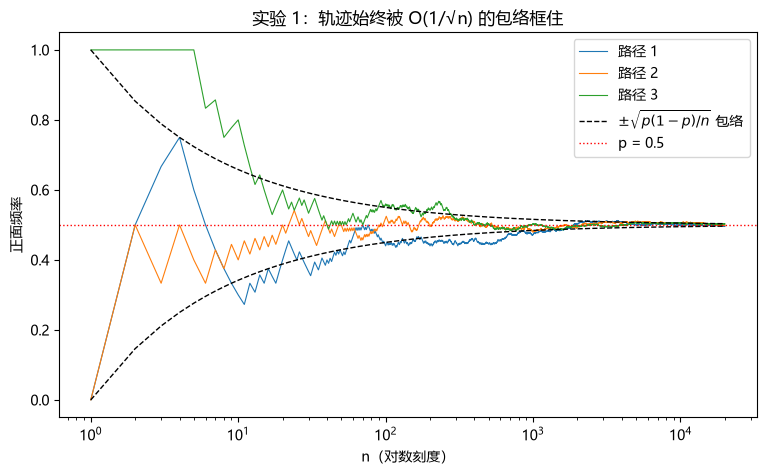

In [2]:
# 实验 1：频率轨迹 + 理论包络 √(p(1-p)/n)
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n = 20000
t = np.arange(1, n + 1)
paths = (rng.random((3, n)) < 0.5).cumsum(axis=1) / t   # 3 条频率轨迹

env = np.sqrt(0.25 / t)                                  # p = 0.5 时 p(1-p) = 0.25
plt.figure(figsize=(9, 5))
for i, f in enumerate(paths):
    plt.plot(t, f, lw=0.8, label=f'路径 {i + 1}')
plt.plot(t, 0.5 + env, 'k--', lw=1, label=r'$\pm\sqrt{p(1-p)/n}$ 包络')
plt.plot(t, 0.5 - env, 'k--', lw=1)
plt.axhline(0.5, color='red', ls=':', lw=1, label='p = 0.5')
plt.xscale('log')
plt.xlabel('n（对数刻度）')
plt.ylabel('正面频率')
plt.title('实验 1：轨迹始终被 O(1/√n) 的包络框住')
plt.legend(loc='upper right')
plt.show()

### 实验 2：方差塌缩的可视化

第 4 节证明过 $\mathrm{Var}(\bar X_n)=\sigma^2/n$。对正态总体 $N(\mu=2,\ \sigma=3)$ 重复抽样，横轴固定同一窗口，看 $n=1,10,100,10000$ 时样本均值的直方图如何从"原始分布"塌缩成一根针，并核对经验方差与理论值。

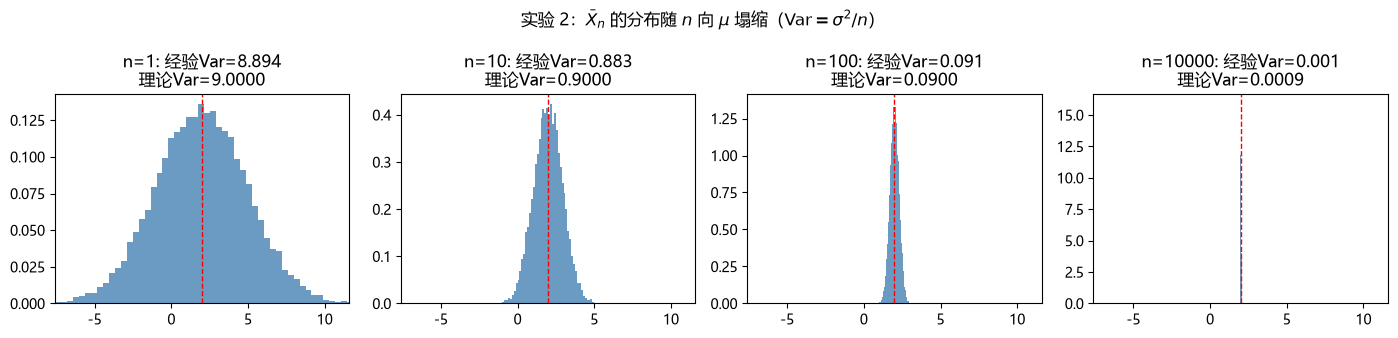

In [3]:
# 实验 2：样本均值的分布随 n 塌缩（方差按 1/n 缩小）
rng = np.random.default_rng(1)
mu, sigma = 2.0, 3.0
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
lo, hi = mu - 3.2 * sigma, mu + 3.2 * sigma              # 固定横轴窗口，便于对比
for ax, n in zip(axes, [1, 10, 100, 10000]):
    reps = 20000 if n <= 100 else 1000
    means = rng.normal(mu, sigma, size=(reps, n)).mean(axis=1)
    ax.hist(means, bins=60, density=True, color='steelblue', alpha=0.8)
    ax.axvline(mu, color='red', ls='--', lw=1)
    ax.set_xlim(lo, hi)
    ax.set_title(f'n={n}: 经验Var={means.var():.3f}\n理论Var={sigma ** 2 / n:.4f}')
plt.suptitle(r'实验 2：$\bar{X}_n$ 的分布随 $n$ 向 $\mu$ 塌缩（$\mathrm{Var}=\sigma^2/n$）')
plt.tight_layout()
plt.show()

### 实验 3：蒙特卡洛估计 π

在单位正方形内均匀撒点，落入四分之一圆的频率 $\approx\pi/4$，乘 4 即得 $\pi$ 的估计。这是大数定律最经典的应用——**把确定性问题转化为随机采样**。

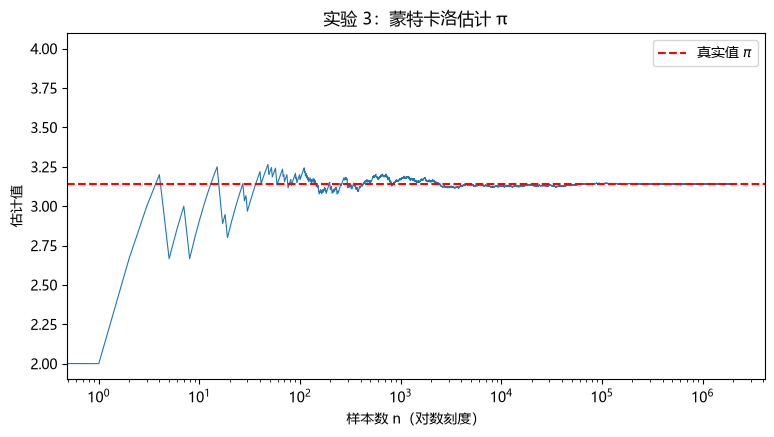

n = 2000000 时估计值 = 3.141984，误差 = 3.91e-04


In [4]:
# 实验 3：蒙特卡洛估计 π（大数定律的第一次实战）
rng = np.random.default_rng(7)
n = 2_000_000
x, y = rng.random(n), rng.random(n)
inside = (x ** 2 + y ** 2) <= 1.0
est = 4.0 * inside.cumsum() / np.arange(1, n + 1)        # 逐步的估计值

plt.figure(figsize=(9, 4.5))
plt.plot(est, lw=0.8)
plt.axhline(np.pi, color='red', ls='--', label=r'真实值 $\pi$')
plt.xscale('log')
plt.xlabel('样本数 n（对数刻度）')
plt.ylabel('估计值')
plt.title('实验 3：蒙特卡洛估计 π')
plt.legend()
plt.show()
print(f'n = {n} 时估计值 = {est[-1]:.6f}，误差 = {abs(est[-1] - np.pi):.2e}')

### 实验 3 的读法：误差的"平方律"

指示函数 $4\cdot\mathbf{1}\{x^2+y^2\le1\}$ 方差恒定，故精度按 $1/\sqrt n$ 改善：

> **想要 10 倍精度，就要 100 倍样本。**

这张"定价表"适用于一切蒙特卡洛方法，也预告了 8.2 节的一个结论：把 mini-batch 扩大 $B$ 倍，梯度噪声只降 $\sqrt B$ 倍——收益天然递减。

## 7. 哲学含义：大数定律告诉了我们关于世界的什么？

### 7.1 概率的"经验根基"被数学封顶

在 Kolmogorov 公理化（1933）之前，"概率"的合法性始终悬而未决：它是主观信念度，还是客观频率？

频率学派的核心信条"**概率 = 长期频率的稳定值**"，正是靠伯努利–波莱尔大数定律闭环的。妙处在于逻辑方向：公理**假设** $\mathbb{P}(A)=p$，定理**推出**频率 $\to p$——于是"用频率估计概率"（整个统计学的地基）从此有了合法性：稳定不是世界仁慈，而是独立重复结构的数学必然。

### 7.2 从个体的无序到整体的秩序

- 单个分子运动不可预测，1 摩尔分子的压强却精确可算——统计力学的全部信心来自 LLN；
- 阿伏伽德罗常数 $N_A\approx6\times10^{23}$，相对涨落 $\sim1/\sqrt{N_A}\sim10^{-12}$：**宏观世界的"确定性"，是微观随机性的大数定律极限**；
- 同构现象随处可见：保险定价（个体死亡时间随机、群体死亡率稳定）、量子测量（单次结果随机、系综统计确定）。

### 7.3 决定论的让步：稳定可以涌现自随机

拉普拉斯妖的世界观是：给定初始条件，一切皆可预测。大数定律提供了另一种世界观——**即使底层完全随机，宏观层面依然可以有精确可预测的规律**。现代物理（量子力学）告诉我们底层就是随机的，而 LLN 保证了随机底层之上仍能建立稳定、可度量、可工程化的世界。可以说，大数定律是连接微观随机性与宏观确定性的一座桥梁。

### 7.4 归纳法的辩护，与它的边界

- 休谟之问：凭什么相信"过去的频率能预测未来"？伯努利的回答：大数定律提供"道德确定性"（moral certainty）——偏差的概率可以任意小；
- 但注意边界：LLN **不告诉你 $p$ 是多少**，它只保证"测得到"；归纳的成功还依赖"世界保持稳定"（独立性、同分布假设）；
- **厚尾警告**：不是一切随机都服从大数定律。柯西分布没有期望，其样本均值 $\bar X_n$ 与单个样本 $X_1$ 同分布——"平均"永远无法驯服它；金融收益率、地震震级、社交网络度数等厚尾世界中，"多次平均就靠谱"可能失效。

> 大数定律的哲学态度：**秩序不是免费的，它是独立性与矩条件的礼物。**

### 7.5 大数定律 ≠ 中心极限定理

- LLN 回答"误差**会不会**消失"：$\bar X_n-\mu\to0$；
- CLT 回答"误差**有多大**"：$\sqrt{n}\,(\bar X_n-\mu)\xrightarrow{d}N(0,\sigma^2)$，即误差量级 $\sim\sigma/\sqrt n$；
- 数值含义：想让估计精度提高一位数，样本量要扩大 **100 倍**——这是所有统计方法（包括深度学习的数据规模焦虑）背后的硬约束。

## 8. 与深度学习的联系：为什么"用数据学规律"是合法的？

### 8.1 经验风险最小化（ERM）：训练目标本身就是样本均值

真实目标（期望风险）：

$$R(f)=\mathbb{E}_{(x,y)\sim P}\big[\ell(f(x),y)\big]$$

实际能算的（经验风险）：

$$R_n(f)=\frac1n\sum_{i=1}^n\ell\big(f(x_i),y_i\big)$$

$R_n(f)$ 正是 $R(f)$ 的样本均值——**没有大数定律，"用训练损失代表真实损失"就无从谈起**。大数定律保证固定的 $f$ 有 $R_n(f)\to R(f)$；要"对所有 $f$ 一致成立"则需要一致收敛与容量控制，那是统计学习理论（VC 维、Rademacher 复杂度）的主题。

### 8.2 小批量 SGD：每天在做的大数定律

全量梯度 $\nabla R(f)=\mathbb{E}[\nabla\ell]$，小批量估计：

$$g_B=\frac1{|B|}\sum_{i\in B}\nabla\ell_i,\qquad \mathbb{E}[g_B]=\nabla R(f),\qquad \mathrm{Var}(g_B)=\frac{\sigma^2}{|B|}$$

- **无偏性**来自 iid 采样（辛钦大数定律），**方差**按 $1/|B|$ 衰减（切比雪夫三步曲）；
- 噪声尺度 $O(1/\sqrt{|B|})$：batch 从 64 增到 256（×4），梯度噪声只降一半——**收益递减**，这正是大批量训练需要重新调学习率的数学原因之一；
- 反过来，训练末期适度的梯度噪声有助于逃离尖锐极小值（SGD 的隐式正则化）——随机性也可以是特性；
- 大语言模型训练中 loss 曲线的小锯齿就是 mini-batch 噪声（$\propto1/\sqrt B$）：你看到的每条曲线，都是对"期望损失"的带噪测量。

### 8.3 其他随处可见的影子

| 场景 | 大数定律的角色 |
| --- | --- |
| Dropout / 数据增强 / 集成学习 | 多次随机估计取平均压方差 |
| MC Dropout（贝叶斯近似） | 多次带 Dropout 的前向传播取平均 = 蒙特卡洛积分 |
| 强化学习中的回报估计 | 策略梯度的回报均值靠 LLN 才有意义；baseline 不改期望、只压方差，加速"LLN 显灵" |
| 蒙特卡洛验证 / 评估 | 一切"采样估期望"的合法性来源 |

一句话总结：**深度学习的每一步参数更新，都是大数定律的一次现场执法。**

## 9. 总结与思考题

### 9.1 四个经典大数定律对比

| 定律 | 年代 | 随机变量 | 核心条件 | 收敛方式 |
| --- | --- | --- | --- | --- |
| 伯努利 LLN | 1713 | 频率 $f_n$ | 独立重复、$\mathrm{Var}(X_i)=pq$ 有界 | 依概率 |
| 切比雪夫 LLN | 1867 | $\bar X_n$ | 独立 + 方差一致有界 $\mathrm{Var}(X_i)\le C$ | 依概率 |
| 辛钦 LLN | 1929 | $\bar X_n$ | iid + **期望存在**（不要求方差） | 依概率 |
| Kolmogorov SLLN | 1930s | $\bar X_n$ | iid + 期望存在 | **几乎必然** |

要点：辛钦的关键贡献是把条件从"方差有界"放松到"只要期望存在"；Kolmogorov 的贡献是把结论从"依概率"升级到"几乎必然"（单条轨迹收敛）。

### 9.2 证明套路回顾

- **弱 LLN 三步曲**：算期望 → 算方差（独立使交叉项消失，$\mathrm{Var}(\bar X_n)=\sigma^2/n$）→ 切比雪夫不等式收尾（$\mathbb{P}(|\bar X_n-\mu|\ge\varepsilon)\le\sigma^2/(n\varepsilon^2)\to0$）；
- **强 LLN 骨架**：Borel–Cantelli 引理 + 子序列技巧（$n_k=k^2$，方块夹梯形）+ Kolmogorov 不等式 + Kronecker 引理；
- 两个不等式的分工：马尔可夫不等式只用矩信息给上界，切比雪夫 = 把 $(X-\mu)^2$ 代入马尔可夫。

### 9.3 三个常见误区

1. **"依概率收敛 + 平凡不足道"？** 否——依概率收敛不保证几乎必然收敛（第 2.5 节的反例），二者的差距恰好是 Borel–Cantelli 与子序列技巧要跨越的鸿沟；
2. **"独立同分布就一定有 LLN"？** 否——柯西分布 iid 但没有期望，LLN 失效；期望的存在性不是技术细节，而是必要条件；
3. **"样本越多误差越小"？** 对单个实现的轨迹不一定单调（会反复穿越），正确说法是**概率意义**上的收敛；且速度只有 $1/\sqrt n$——10 倍精度要 100 倍样本。

### 9.4 延伸阅读

- 《概率论沉思录》（E.T. Jaynes）——LLN 在贝叶斯视角下的意义；
- Durrett, *Probability: Theory and Examples*, 第 1–2 章——SLLN 的完整现代证明；
- Williams, *Probability with Martingales*——用鞅观点重看 LLN；
- 《深度学习》（Goodfellow 等）第 5 章——机器学习中的 LLN 与估计量。

### 9.5 思考题

**Q1（切比雪夫 vs CLT 的精度差距）**：iid $\mathrm{Bernoulli}(0.5)$，$n=10^4$。用切比雪夫不等式估计 $\mathbb{P}(|\bar X_n-0.5|\ge0.01)$ 的上界；再用 CLT 近似算真实量级。二者差多少？

> 提示：切比雪夫给 $p(1-p)/(n\varepsilon^2)=0.25/(10^4\times10^{-4})=0.25$（几乎没用）；CLT 给 $\approx 2\Phi(-2)\approx4.55\%$。切比雪夫是"零知识"界（只用方差），CLT 用了分布形状——差距提醒我们：界是保证，近似是精度。

**Q2（柯西的顽固）**：$X_1,\dots,X_n$ iid 标准柯西。证明 $\bar X_n=\frac1n\sum X_i$ 与 $X_1$ **同分布**（可用特征函数 $\varphi(t)=e^{-|t|}$）。这对"用平均来估计柯西位置参数"意味着什么？正确的做法是什么？

> 提示：$n$ 个柯西之和仍是柯西（尺度放大 $n$ 倍），除以 $n$ 后分布不变——平均永远无法降低不确定性。正确做法：用中位数或截尾均值，它们对厚尾稳健。

**Q3（batch 的边际收益）**：SGD 梯度噪声尺度 $\propto1/\sqrt{|B|}$。若把 batch 从 128 提到 512，噪声降到原来的几分之一？想保持"噪声减半"的效果，batch 需要扩大几倍？结合算力成本，谈谈为什么实践常用"增大 batch 的同时等比例增大学习率"。

> 提示：$\sqrt{128/512}=1/2$，噪声减半；但下次再减半需要 ×4 的算力——平方律的代价。线性缩放学习率（$\eta\propto|B|$）是补偿小噪声、维持有效步长的一种常用策略。